In [1]:
import sys
import numpy as np
import torch 
# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
# get UMAP
import umap

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

<module 'factor_model' from '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py'>

In [2]:
leaflet_repo = '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-binomial-mix/'
sys.path.append(leaflet_repo)
import load_cluster_data
from betabinomo_mix_singlecells import *

### Settings and Load data

In [3]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cuda


In [4]:
input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/'

cell_types = ['Brain_Non-Myeloid_brain_pericyte','Brain_Non-Myeloid_oligodendrocyte_precursor_cell','Brain_Non-Myeloid_endothelial_cell','Brain_Non-Myeloid_oligodendrocyte',
 'Brain_Non-Myeloid_neuron', 'Brain_Myeloid_macrophage',
 'Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte']

#ignoring Bergmann_glial_cell since very few cells

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=5000, celltypes=cell_types, has_genes="yes") 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/
Finished reading in data from folder ...
Looking at only specific cell types ...['Brain_Non-Myeloid_brain_pericyte', 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell', 'Brain_Non-Myeloid_endothelial_cell', 'Brain_Non-Myeloid_oligodendrocyte', 'Brain_Non-Myeloid_neuron', 'Brain_Myeloid_macrophage', 'Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte']
['Brain_Non-Myeloid_brain_pericyte'
 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell'
 'Brain_Non-Myeloid_endothelial_cell' 'Brain_Non-Myeloid_oligodendrocyte'
 'Brain_Non-Myeloid_neuron' 'Brain_Myeloid_macrophage'
 'Brain_Myeloid_microglial_cell' 'Brain_Non-Myeloid_astrocyte']
7816
16190
The maximum junction count was initially:  150346
80
The maximum junction count is now:  4982
                                             cell_id  Cluster  Cluster_Counts  \
0  A14-MAA000581-3_10_M-1-1_Brain_Non-M

In [5]:
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

The number of cells going into training data is:
7816
7816


/gpfs/commons/home/kisaev/Leaflet-private/src/beta-binomial-mix/betabinomo_mix_singlecells.py:333: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount_lookup = torch.sparse_coo_tensor(


In [6]:
simple_data = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

### Get ready for model training 

In [7]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

In [8]:
indices = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(final_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = final_data['cell_id_index'].max() + 1
num_junctions = final_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [9]:
indices_counts = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(final_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = final_data['cell_id_index'].max() + 1
num_junctions_counts = final_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [10]:
# save full dataset y_tensor and total_counts_tensor 
full_y_tensor = y_tensor
full_total_counts_tensor = total_counts_tensor

## Evaluate performance on imputation/masking task

In [11]:
# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations')
import masking
from masking import *

# import reload 
from importlib import reload
reload(masking)

<module 'masking' from '/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py'>

In [12]:
#1. get masked matrix using intron cluster counts for this mouse brain data 
masking_percs = [0.1, 0.5, 0.99]
masks_list = []

# get masked matrix for each masking percentage

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting masked matrix for each masking percentage")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for perc_mask in masking_percs:
    print("The masking percentage is: " + str(perc_mask))
    masked_matrix = generate_mask(cluster_counts, mask_percentage = perc_mask)
    masks_list.append(masked_matrix)

#2. get junction and intron cluster count matrices with masked values 
masked_counts = []

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting junction and intron cluster count matrices with masked values")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for i in range(len(masking_percs)):
    print("The masking percentage is: " + str(masking_percs[i]))
    masked_junction_counts, masked_intron_clusts = apply_mask(junc_counts, cluster_counts, masks_list[i])
    # appent masked junction and intron cluster counts to list
    masked_counts.append((masked_junction_counts, masked_intron_clusts))

#3. get input files for factor model (junction and intron cluster sparse tensor)
model_input_files = [] 

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting input files for factor model")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for i in range(len(masking_percs)):
    print("The masking percentage is: " + str(masking_percs[i]))
    masked_junction_counts, masked_intron_clusts = masked_counts[i]
    # get y_tensor and total_counts_tensor via prep_model_input function
    y_tensor, total_counts_tensor = prep_model_input(masked_junction_counts, masked_intron_clusts)
    # append to model_input_files list
    model_input_files.append((y_tensor, total_counts_tensor))

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Getting masked matrix for each masking percentage
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
The masking percentage is: 0.1
Number of entries (junction-cell pairs) masked:  1054635.0
The masking percentage is: 0.5
Number of entries (junction-cell pairs) masked:  5273177.0
The masking percentage is: 0.99
Number of entries (junction-cell pairs) masked:  10440890.0
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Getting junction and intron cluster count matrices with masked values
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
The masking percentage is: 0.1
The masking percentage is: 0.5
The masking percentage is: 0.99
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Getting input files for factor model
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
The masking percentage is: 0.1


/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py:130: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:245.)
  indices = torch.tensor(np.nonzero(masked_intron_clusts), dtype=torch.long)


The masking percentage is: 0.5
The masking percentage is: 0.99


In [14]:
# Now can run factor model on masked data
Ks = [8, 20, 100]
all_Ks_results = {}

for k in Ks:
    
    print("------------------------------------------------")
    print("Running factor model for K = " + str(k))
    print("------------------------------------------------")
    
    # now also iterate over masking percentages 
    for i in range(len(masking_percs)):
        print("The masking percentage is: " + str(masking_percs[i]))
        y_tensor, total_counts_tensor = model_input_files[i]
        # run factor model
        masked_results = factor_model.main(y_tensor, total_counts_tensor, num_initializations=3, use_global_prior=False, K=k, lr=0.1, loss_plot=False, num_epochs=100, save_to_file = False)
        # save results to dictionary
        all_Ks_results[(k, masking_percs[i])] = masked_results

# Get pearson correlation and l1 error between true and inferred parameters (PSI)
masked_perf = []

for k in Ks:
    for perc_mask in masking_percs:
        print("Calculating performance for K = " + str(k) + " and masking percentage = " + str(perc_mask))
        masked_results = all_Ks_results[(k, perc_mask)]        
        for res in masked_results:
            # get seed that was used 
            seed = res['seed']

            # get latent variables
            psi = res['latent_vars']["psi"] # psi is the probability of a junction being used in a cluster
            assign_post=res['latent_vars']["assign"]

            # get K 
            K = psi.shape[0]
            J = psi.shape[1]

            # get scores 
            mask_matrix_used = masks_list[i]
            l1, r, l2 = evaluate_model(junc_counts.toarray(), cluster_counts.toarray(), psi, assign_post, mask_matrix_used)

            # get num epochs trained for 
            nepoch = len(res["losses"])

            # save to list 
            masked_perf.append([seed, l1, r, l2, K, perc_mask, J, nepoch])

# make masked_perf a dataframe 
masked_perf_df = pd.DataFrame(masked_perf, columns=["seed", "l1", "r", "l2", "K",  "perc_masked" , "J", "num_epochs"])

------------------------------------------------
Running factor model for K = 8
------------------------------------------------
The masking percentage is: 0.1
Not using priors on a and b, running simpler non-hierarchical version!
Initialization 1 with seed 2880
Define the guide
Fit the model
Epoch 0, Loss: 188958810.58149087


Epoch 10, Loss: 108631317.88121355
Epoch 20, Loss: 78217644.06632072
Epoch 30, Loss: 67006641.534072906
Epoch 40, Loss: 62236019.53673133
Epoch 50, Loss: 59669813.01233283
Epoch 60, Loss: 58116372.14755736
Epoch 70, Loss: 57132619.79164347
Epoch 80, Loss: 56469977.63546173
Epoch 90, Loss: 56005732.76635711
Sample from the guide (posterior)
Extract the latent variables
Initialization 2 with seed 3286
Define the guide
Fit the model
Epoch 0, Loss: 164880192.85653967
Epoch 10, Loss: 97255734.7775577
Epoch 20, Loss: 73688829.5968678
Epoch 30, Loss: 64839720.769387476
Epoch 40, Loss: 60978348.72029458
Epoch 50, Loss: 58912990.86724992
Epoch 60, Loss: 57652479.84924769
Epoch 70, Loss: 56824619.92841154
Epoch 80, Loss: 56228904.82698418
Epoch 90, Loss: 55788560.078030154
Sample from the guide (posterior)
Extract the latent variables
Initialization 3 with seed 1588
Define the guide
Fit the model
Epoch 0, Loss: 160784403.90932
Epoch 10, Loss: 95635732.64732505
Epoch 20, Loss: 74231488.63235223
E

/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py:178: RuntimeWarning: invalid value encountered in divide
  true_psi = true_juncs / true_clusts


L1 error:  0.16294551005230887
Spearman correlation:  0.7294994285254183
L2 error:  0.06565554709824921
L1 error:  0.16349643909374834
Spearman correlation:  0.7286548033219188
L2 error:  0.06579595999311418
L1 error:  0.16380544765015453
Spearman correlation:  0.7278821765922822
L2 error:  0.0659832283851747
Calculating performance for K = 8 and masking percentage = 0.5
L1 error:  0.16455571100360608
Spearman correlation:  0.7246463222102003
L2 error:  0.06685521166603077
L1 error:  0.1644997779152081
Spearman correlation:  0.7236506565256056
L2 error:  0.06692965962705442
L1 error:  0.16799220144566906
Spearman correlation:  0.7187690136153557
L2 error:  0.06810019088895461
Calculating performance for K = 8 and masking percentage = 0.99
L1 error:  0.22712998256899286
Spearman correlation:  0.5396344383407041
L2 error:  0.11134251225884288
L1 error:  0.22534786669069695
Spearman correlation:  0.542756360406438
L2 error:  0.11140416887632985
L1 error:  0.2252186741905627
Spearman corre

#### Make plots 

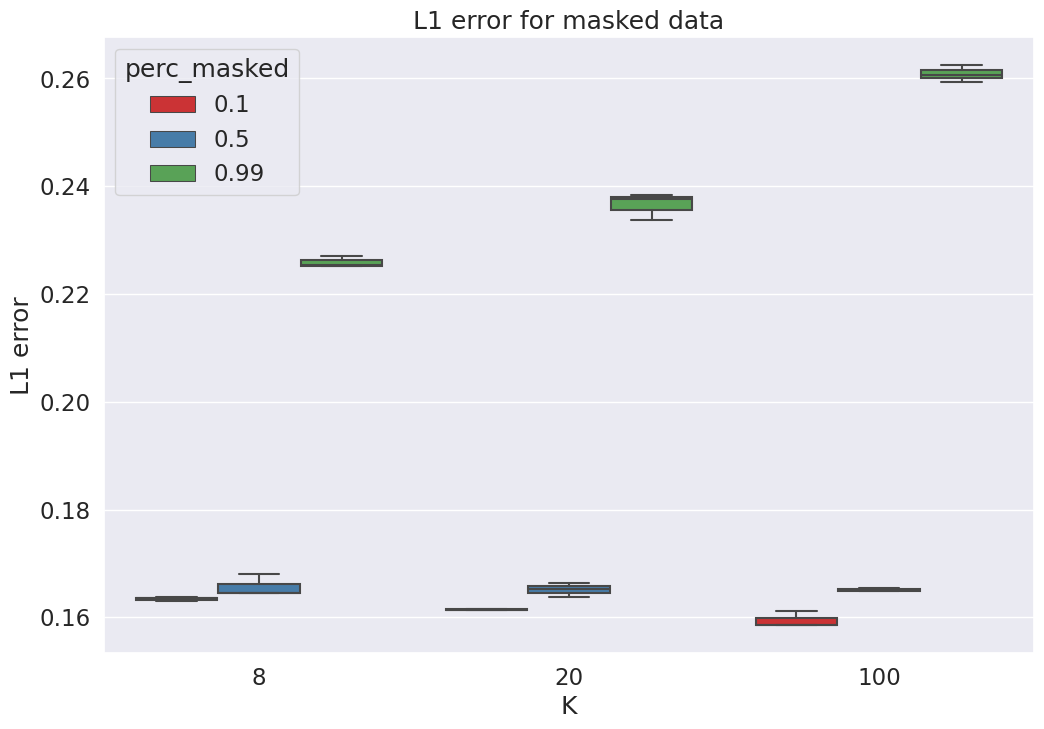

0.15852756671537235


In [15]:
# make boxplot of l1 error for each K and masking percentage
# sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 8))

# use sns catplot to show K and perc masked
ax = sns.boxplot(x="K", y="l1", hue="perc_masked", data=masked_perf_df, palette="Set1")
ax.set_xlabel("K")
ax.set_ylabel("L1 error")
ax.set_title("L1 error for masked data")
plt.show()
print(masked_perf_df.l1.min())


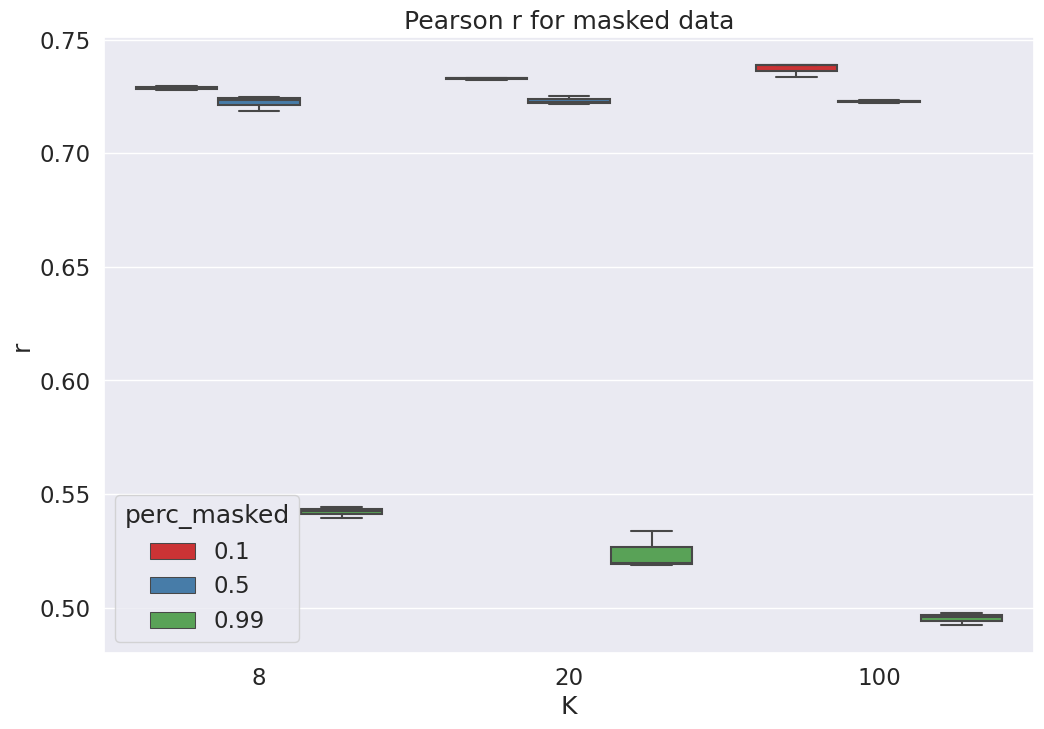

0.7387658135264356


In [16]:
# make boxplot for r 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 8))

ax = sns.boxplot(x="K", y="r", hue="perc_masked", data=masked_perf_df, palette="Set1")
ax.set_xlabel("K")
ax.set_ylabel("r")
ax.set_title("Spearman r for masked data")
plt.show()
print(masked_perf_df.r.max())

In [17]:
# get median l1 error and pearson r for each K and across all masking percentages
median_l1 = masked_perf_df.groupby(["K"])["l1"].median()
median_r = masked_perf_df.groupby(["K"])["r"].median()
print(median_l1)
print(median_r)

K
8      0.164556
20     0.165253
100    0.164984
Name: l1, dtype: float64
K
8      0.723651
20     0.722452
100    0.723010
Name: r, dtype: float64


Axes(0.125,0.11;0.775x0.77)


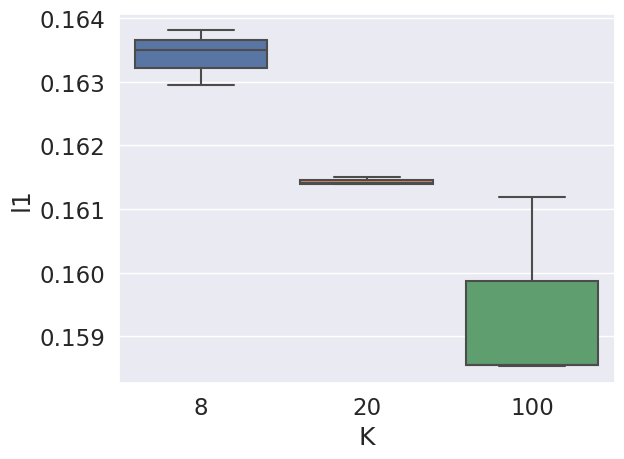

In [18]:
per01 = masked_perf_df[masked_perf_df["perc_masked"] == 0.1]

# make boxplot of l1 error for each K and masking percentage
print(sns.boxplot(x="K", y="l1", data=per01))

In [ ]:
print(sns.boxplot(x="K", y="l2", data=per01))

Axes(0.125,0.11;0.775x0.77)


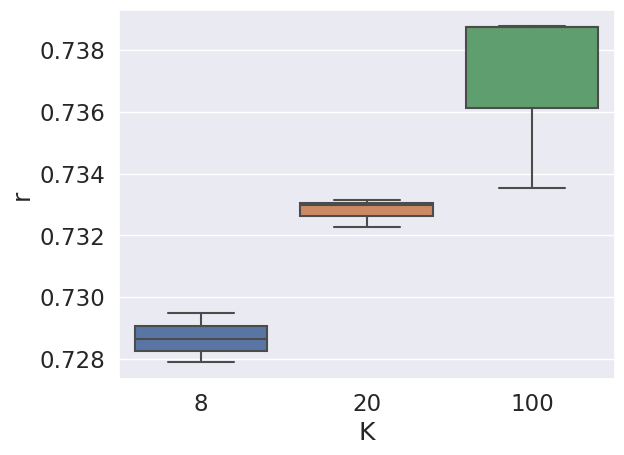

In [19]:
print(sns.boxplot(x="K", y="r", data=per01))

## Try now with global priors on a and b 

In [20]:
# Now can run factor model on masked data
Ks = [8, 20, 100]
all_Ks_results = {}

for k in Ks:
    
    print("------------------------------------------------")
    print("Running factor model for K = " + str(k))
    print("------------------------------------------------")
    
    # now also iterate over masking percentages 
    for i in range(len(masking_percs)):
        print("The masking percentage is: " + str(masking_percs[i]))
        y_tensor, total_counts_tensor = model_input_files[i]
        # run factor model
        masked_results = factor_model.main(y_tensor, total_counts_tensor, num_initializations=3, use_global_prior=False, K=k, lr=0.1, loss_plot=False, num_epochs=100, save_to_file = False)
        # save results to dictionary
        all_Ks_results[(k, masking_percs[i])] = masked_results

# Get pearson correlation and l1 error between true and inferred parameters (PSI)
masked_perf = []

for k in Ks:
    for perc_mask in masking_percs:
        print("Calculating performance for K = " + str(k) + " and masking percentage = " + str(perc_mask))
        masked_results = all_Ks_results[(k, perc_mask)]        
        for res in masked_results:
            # get seed that was used 
            seed = res['seed']

            # get latent variables
            psi = res['latent_vars']["psi"] # psi is the probability of a junction being used in a cluster
            assign_post=res['latent_vars']["assign"]

            # get K 
            K = psi.shape[0]
            J = psi.shape[1]

            # get scores 
            mask_matrix_used = masks_list[i]
            l1, r, l2 = evaluate_model(junc_counts.toarray(), cluster_counts.toarray(), psi, assign_post, mask_matrix_used)

            # get num epochs trained for 
            nepoch = len(res["losses"])

            # save to list 
            masked_perf.append([seed, l1, r, l2, K, perc_mask, J, nepoch])

# make masked_perf a dataframe 
masked_perf_df = pd.DataFrame(masked_perf, columns=["seed", "l1", "r", "l2", "K",  "perc_masked" , "J", "num_epochs"])

------------------------------------------------
Running factor model for K = 8
------------------------------------------------
The masking percentage is: 0.1
Not using priors on a and b, running simpler non-hierarchical version!
Initialization 1 with seed 1247
Define the guide
Fit the model
Epoch 0, Loss: 164463581.97030538
Epoch 10, Loss: 95240968.15042716
Epoch 20, Loss: 73720355.82467523
Epoch 30, Loss: 65251025.633208156
Epoch 40, Loss: 61168237.95143017
Epoch 50, Loss: 59049238.24213163
Epoch 60, Loss: 57753203.269048154
Epoch 70, Loss: 56917559.18207088
Epoch 80, Loss: 56317161.15600775
Epoch 90, Loss: 55873534.56926362
Sample from the guide (posterior)
Extract the latent variables
Initialization 2 with seed 5051
Define the guide
Fit the model
Epoch 0, Loss: 209524354.05991033
Epoch 10, Loss: 121013662.20046224
Epoch 20, Loss: 84456391.19026223
Epoch 30, Loss: 70077630.12854964
Epoch 40, Loss: 64113715.63461529
Epoch 50, Loss: 61018015.1317354
Epoch 60, Loss: 59087094.7312929
E

/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py:178: RuntimeWarning: invalid value encountered in divide
  true_psi = true_juncs / true_clusts


L1 error:  0.1639514165620411
Spearman correlation:  0.727833671931883
L2 error:  0.06600409911910626
L1 error:  0.16366492751480463
Spearman correlation:  0.7280402295982699
L2 error:  0.06586658739287682
L1 error:  0.16738510313807264
Spearman correlation:  0.7225251423317512
L2 error:  0.06743374264347826
Calculating performance for K = 8 and masking percentage = 0.5
L1 error:  0.16434062917899947
Spearman correlation:  0.7241281045644385
L2 error:  0.06689951837969126
L1 error:  0.169575848591803
Spearman correlation:  0.717043016035014
L2 error:  0.06806838668541207
L1 error:  0.16530342069258694
Spearman correlation:  0.7219854412839781
L2 error:  0.06725849156894577
Calculating performance for K = 8 and masking percentage = 0.99
L1 error:  0.22420796700002693
Spearman correlation:  0.5477767777363175
L2 error:  0.11081504841914751
L1 error:  0.2286795142950506
Spearman correlation:  0.5368067132751521
L2 error:  0.11095862284706075
L1 error:  0.22425771620554055
Spearman correla

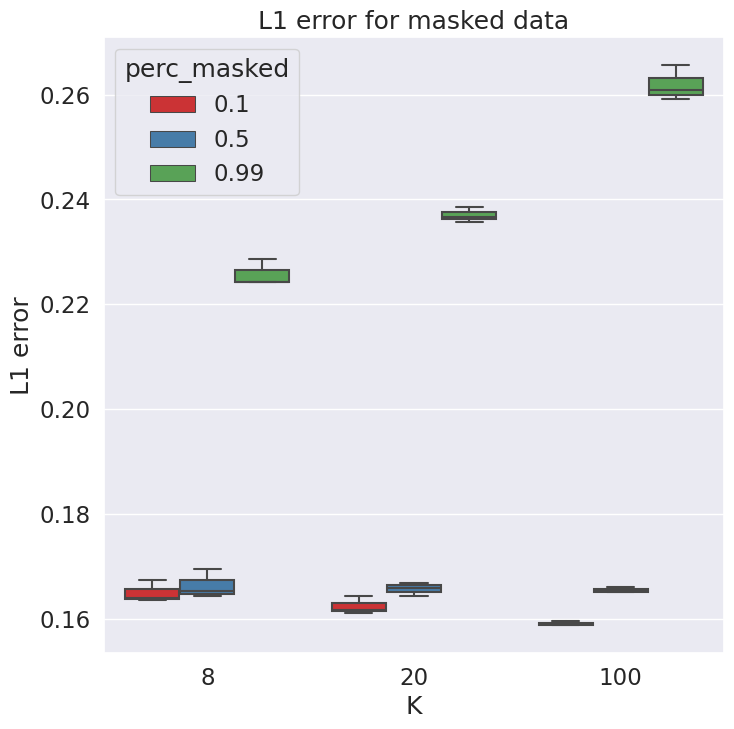

0.15884117709001072


In [34]:
# make boxplot of l1 error for each K and masking percentage
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 8))

# use sns catplot to show K and perc masked
ax = sns.boxplot(x="K", y="l1", hue="perc_masked", data=masked_perf_df, palette="Set1")
ax.set_xlabel("K")
ax.set_ylabel("L1 error")
ax.set_title("L1 error for masked data")
plt.show()
print(masked_perf_df.l1.min())

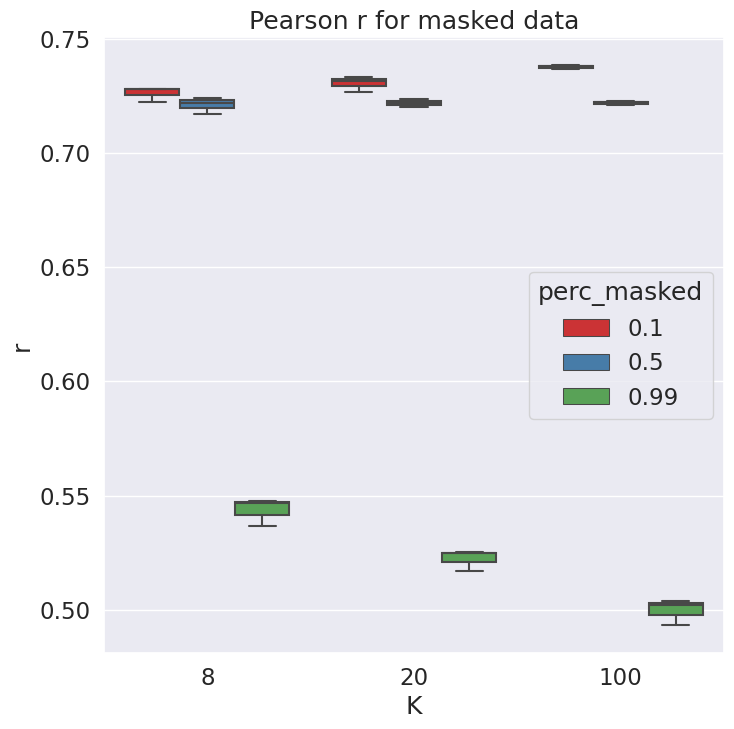

0.7384106534459277


In [35]:
# make boxplot for r 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 8))

ax = sns.boxplot(x="K", y="r", hue="perc_masked", data=masked_perf_df, palette="Set1")
ax.set_xlabel("K")
ax.set_ylabel("r")
ax.set_title("Spearman r for masked data")
plt.show()
print(masked_perf_df.r.max())

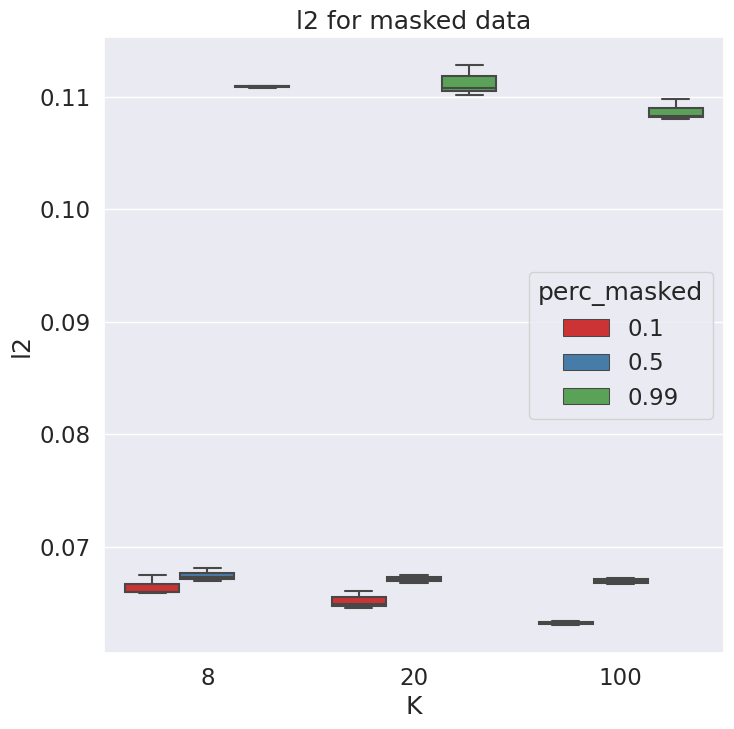

0.06300705420270573


In [38]:
# make boxplot for r 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 8))

ax = sns.boxplot(x="K", y="l2", hue="perc_masked", data=masked_perf_df, palette="Set1")
ax.set_xlabel("K")
ax.set_ylabel("l2")
ax.set_title("l2 for masked data")
plt.show()
print(masked_perf_df.l2.min())

In [23]:
# get median l1 error and pearson r for each K and across all masking percentages
median_l1 = masked_perf_df.groupby(["K"])["l1"].median()
median_r = masked_perf_df.groupby(["K"])["r"].median()
print(median_l1)
print(median_r)

K
8      0.167385
20     0.166003
100    0.165372
Name: l1, dtype: float64
K
8      0.721985
20     0.722066
100    0.722130
Name: r, dtype: float64


Axes(0.125,0.11;0.775x0.77)


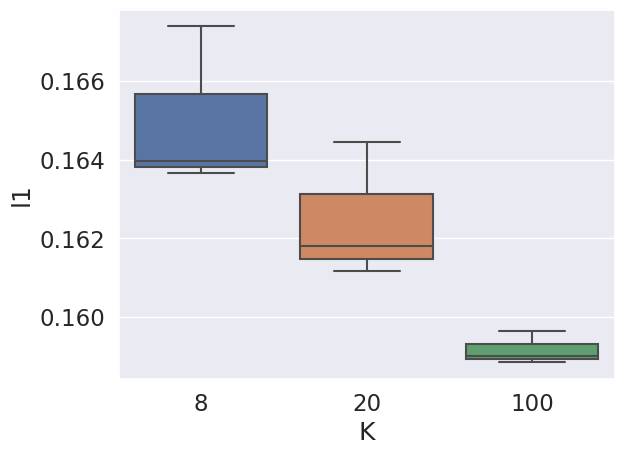

In [24]:
per01 = masked_perf_df[masked_perf_df["perc_masked"] == 0.1]

# make boxplot of l1 error for each K and masking percentage
print(sns.boxplot(x="K", y="l1", data=per01))

Axes(0.125,0.11;0.775x0.77)


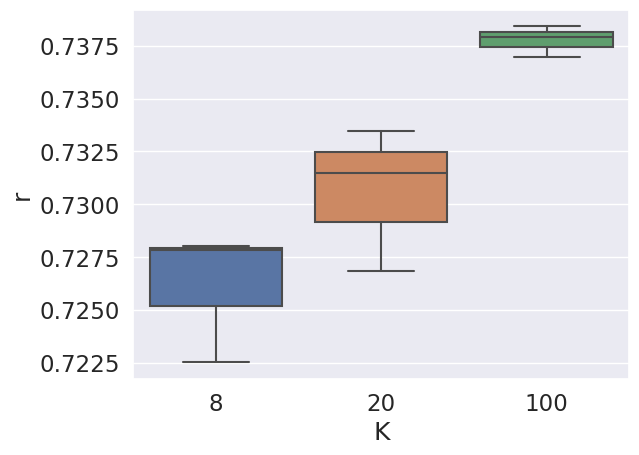

In [25]:
print(sns.boxplot(x="K", y="r", data=per01))

## Run full factor model! 

Using prior for a and b per junction to model average behaviour!
Initialization 1 with seed 1227
Define the guide
Fit the model
Epoch 0, Loss: 264149583.87542167


Epoch 10, Loss: 150900693.25296247
Epoch 20, Loss: 100262322.91554046
Epoch 30, Loss: 77819801.70417309
Epoch 40, Loss: 68299002.64568329
Epoch 50, Loss: 63832661.24843454
Epoch 60, Loss: 61329029.75669646
Epoch 70, Loss: 59630009.04134202
Epoch 80, Loss: 58488636.97430682
Epoch 90, Loss: 57599176.58938074
Epoch 100, Loss: 56886456.642011404
Epoch 110, Loss: 56287762.526096106
Epoch 120, Loss: 55798343.35668826
Epoch 130, Loss: 55349867.350075245
Epoch 140, Loss: 55002828.70675039


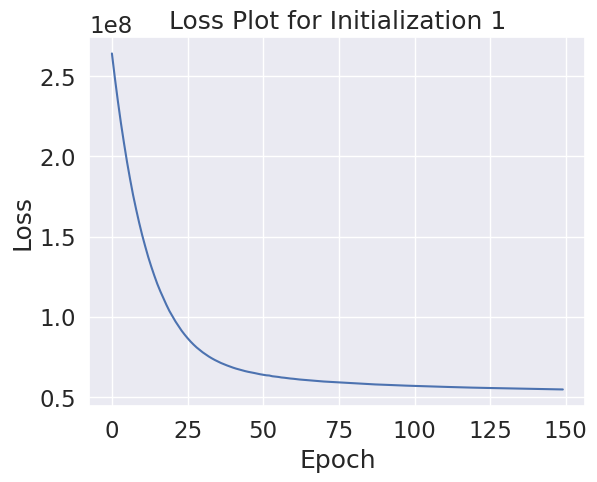

Sample from the guide (posterior)
Extract the latent variables
Initialization 2 with seed 8511
Define the guide
Fit the model
Epoch 0, Loss: 265187461.8635186
Epoch 10, Loss: 151958116.68972704
Epoch 20, Loss: 101196911.74179924
Epoch 30, Loss: 78162576.9094156
Epoch 40, Loss: 68153311.50269866
Epoch 50, Loss: 63615423.07079053
Epoch 60, Loss: 61170224.72522497
Epoch 70, Loss: 59510632.07970929
Epoch 80, Loss: 58318038.322024584
Epoch 90, Loss: 57377114.58562517
Epoch 100, Loss: 56629802.107120275
Epoch 110, Loss: 56017933.76793671
Epoch 120, Loss: 55512808.092746735
Epoch 130, Loss: 55072323.6928854
Epoch 140, Loss: 54739982.68602157


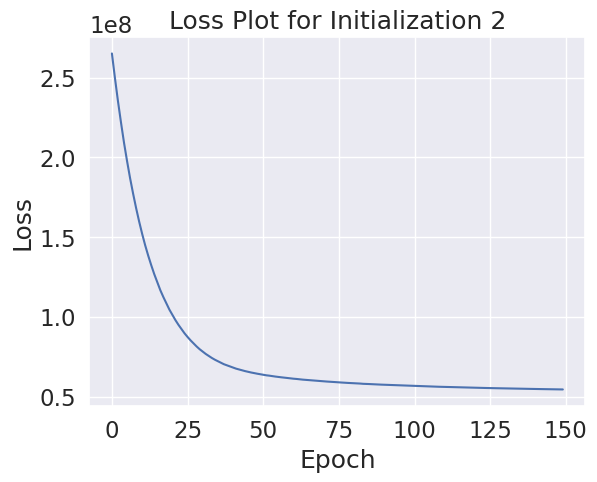

Sample from the guide (posterior)
Extract the latent variables
All initializations complete. Returning results.
------------------------------------------------


In [40]:
reload(factor_model)
best_K = 100 
K = best_K

all_results = factor_model.main(full_y_tensor, full_total_counts_tensor, num_initializations=2, use_global_prior=False, K=100, lr=0.1, loss_plot=True, num_epochs=150, save_to_file = False)

In [41]:
# extract latent variables for just first seed used 
latent_vars = all_results[0]['latent_vars'] 
pi = latent_vars["pi"] # overall contribution of each factor to cell population, one value per k
conc = latent_vars["conc"] # one scaling value 

assign_post = latent_vars["assign"]

psis = latent_vars["psi"] # psi is the probability of a junction being used in a cluster

a = latent_vars["a"] 
b = latent_vars["b"] 
print(a)
print(b)

print("The inferred concentration parameter is: " + str(conc))
print("The inferred pi parameter is: " + str(pi))

[1.8442248  1.8019147  0.6697986  ... 0.6169875  1.1859131  0.76593745]
[2.402279   1.6803291  0.51645696 ... 3.1566887  1.2923644  0.914469  ]
The inferred concentration parameter is: 16.89436
The inferred pi parameter is: [0.0122068  0.01804526 0.01226668 0.01169927 0.0238461  0.02356829
 0.01265695 0.0116613  0.04153525 0.01017797 0.01505331 0.01222639
 0.0120009  0.01400095 0.01333863 0.01619081 0.01119671 0.01112425
 0.01059116 0.01208257 0.00993672 0.03706755 0.02953942 0.01380914
 0.01039618 0.01188828 0.01317968 0.01193714 0.00950875 0.01245986
 0.01165016 0.02342622 0.01165702 0.01003375 0.01292756 0.00935092
 0.01297053 0.00900582 0.01190821 0.01064686 0.00918237 0.00866206
 0.01268584 0.00920714 0.00971876 0.00878716 0.01135482 0.00908531
 0.01359864 0.0078176  0.00930633 0.00974526 0.00837715 0.0096121
 0.00734425 0.00744368 0.00883573 0.0092883  0.01052121 0.00732453
 0.00973919 0.0076848  0.007701   0.00828157 0.00907715 0.00762932
 0.00788779 0.00717631 0.00770436 0.0075

### Evaluate latent variables 

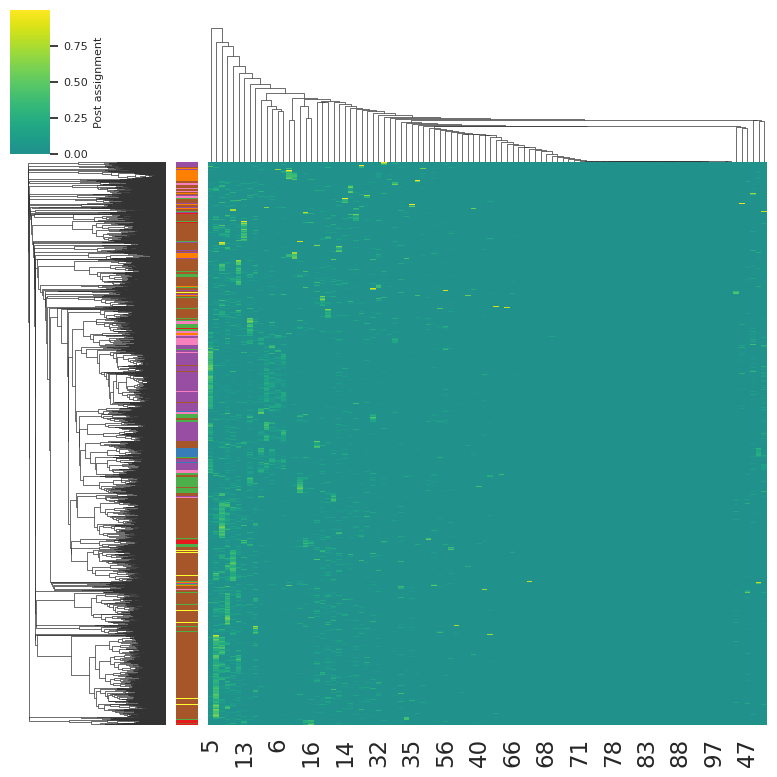

In [42]:
color_palette = sns.color_palette("Set1", n_colors=len(cell_ids_conversion['cell_type'].unique()))
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion['cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_ids_conversion.cell_type.values

# create colours for each cell type 
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

cluster = sns.clustermap(
    data=assign_post,
    method='complete',
    cmap="viridis",
    annot=False,
    fmt=".2f",
    yticklabels=False,
    figsize=(8, 8),
    center=0,
    row_colors=row_colors,  # Apply row colors
    cbar_kws={'label': 'Post assignment'} 
    )
cluster.cax.set_ylabel('Post assignment', size=8)
# Increase font size for color bar tick labels:
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(8)

The silhouette score for K = 100 is: 0.070911184
The Davies Bouldin score for K = 100 is: 3.390769552292681


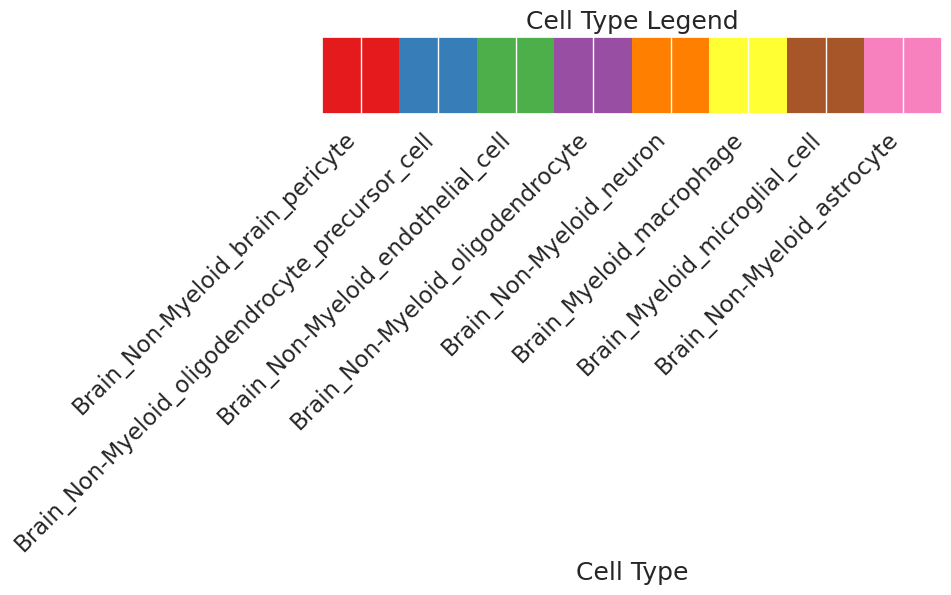

In [43]:
# print cell type color legend seperately
cell_type_colors
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)
sns.palplot(color_palette)
plt.title("Cell Type Legend")
# add cell type names to legend
plt.xticks(np.arange(len(unique_cell_types)), unique_cell_types, rotation=45, ha='right')
plt.xlabel("Cell Type")

# let's calculate silhouette score ussing assign_post
ss = silhouette_score(assign_post, cell_types)
# print with K equals K the ss is 
print("The silhouette score for K = " + str(K) + " is: " + str(ss))

# get davies bouldin score
from sklearn.metrics import davies_bouldin_score
dbs = davies_bouldin_score(assign_post, cell_types)
print("The Davies Bouldin score for K = " + str(K) + " is: " + str(dbs))

In [44]:
# make UMAP using average assign_post across seeds and color points by cell_type 
reducer = umap.UMAP()
embedding = reducer.fit_transform(assign_post)

/scratch/ipykernel_165903/908986799.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


Text(0, 0.5, 'UMAP 2')

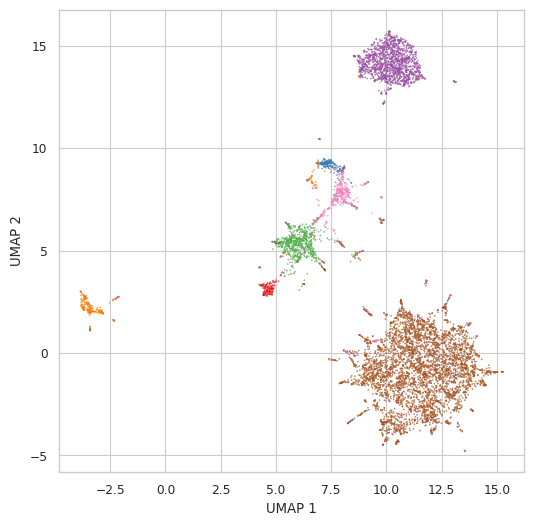

In [45]:
# plot UMAP 
# add whitegrid 
sns.set_style("whitegrid")
sns.set_context("paper")
plt.figure(figsize=(6, 6))
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[cell_type_colors[cell_type] for cell_type in cell_types],
    s=0.1,
    cmap="Spectral",
)
# xlab 
plt.xlabel("UMAP 1")
# ylab
plt.ylabel("UMAP 2")

([<matplotlib.axis.XTick at 0x7fbd9839e670>,
 [Text(0, 0, 'Brain_Non-Myeloid_brain_pericyte'),
  Text(1, 0, 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell'),
  Text(2, 0, 'Brain_Non-Myeloid_endothelial_cell'),
  Text(3, 0, 'Brain_Non-Myeloid_oligodendrocyte'),
  Text(4, 0, 'Brain_Non-Myeloid_neuron'),
  Text(5, 0, 'Brain_Myeloid_macrophage'),
  Text(6, 0, 'Brain_Myeloid_microglial_cell'),
  Text(7, 0, 'Brain_Non-Myeloid_astrocyte')])

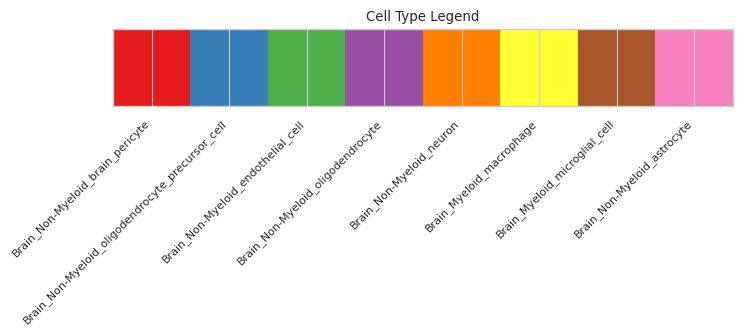

In [46]:
# plot cell_type_colors legend
sns.palplot(color_palette)
plt.title("Cell Type Legend")
# add cell type names to legend
plt.xticks(np.arange(len(unique_cell_types)), unique_cell_types, rotation=45, ha='right', size=8)

[0.12631954 0.07258736 0.06635435 0.05697507 0.05115325 0.04063139
 0.03600901 0.03445805 0.02535686 0.02330446]


/scratch/ipykernel_165903/2434076237.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


Text(0, 0.5, 'PC 2')

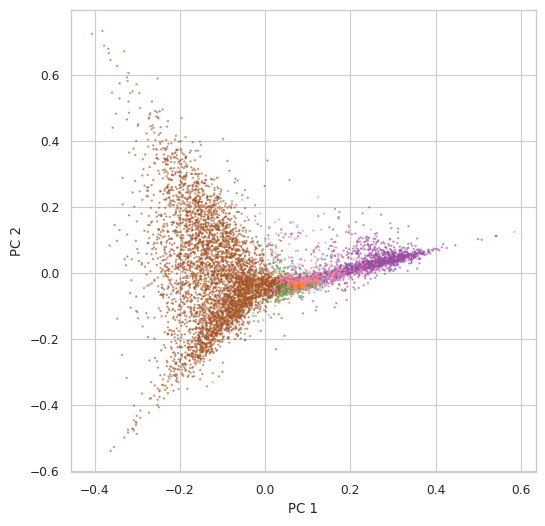

In [47]:
# now run PCA on assign_post 
pca = PCA(n_components=10)
pca.fit(assign_post)
print(pca.explained_variance_ratio_)

pcs = pca.transform(assign_post)
pcs_df = pd.DataFrame(pcs, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10"])
cell_types_pcs = cell_ids_conversion["cell_type"]

sns.set_style("whitegrid")
sns.set_context("paper")

plt.figure(figsize=(6, 6))
plt.scatter(
    pcs_df["PC1"],
    pcs_df["PC2"],
    c=[cell_type_colors[cell_type] for cell_type in cell_types],
    s=0.8, alpha=0.5, 
    cmap="Spectral",
)
# xlab 
plt.xlabel("PC 1")
# ylab
plt.ylabel("PC 2")